Importing Modules

In [255]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

Importing Dataset

In [ ]:
df = pd.read_csv("../data/loan_approval_data.csv")

Filling Missing Data

In [222]:
num_columns = df.select_dtypes(include=["number"]).columns
cat_columns = df.select_dtypes(include=["object"]).columns
num_impute = SimpleImputer(strategy="mean")
cat_impute = SimpleImputer(strategy="most_frequent")

df[num_columns] = num_impute.fit_transform(df[num_columns])
df[cat_columns] = cat_impute.fit_transform(df[cat_columns])

EDA - Exploratory Data Analysis

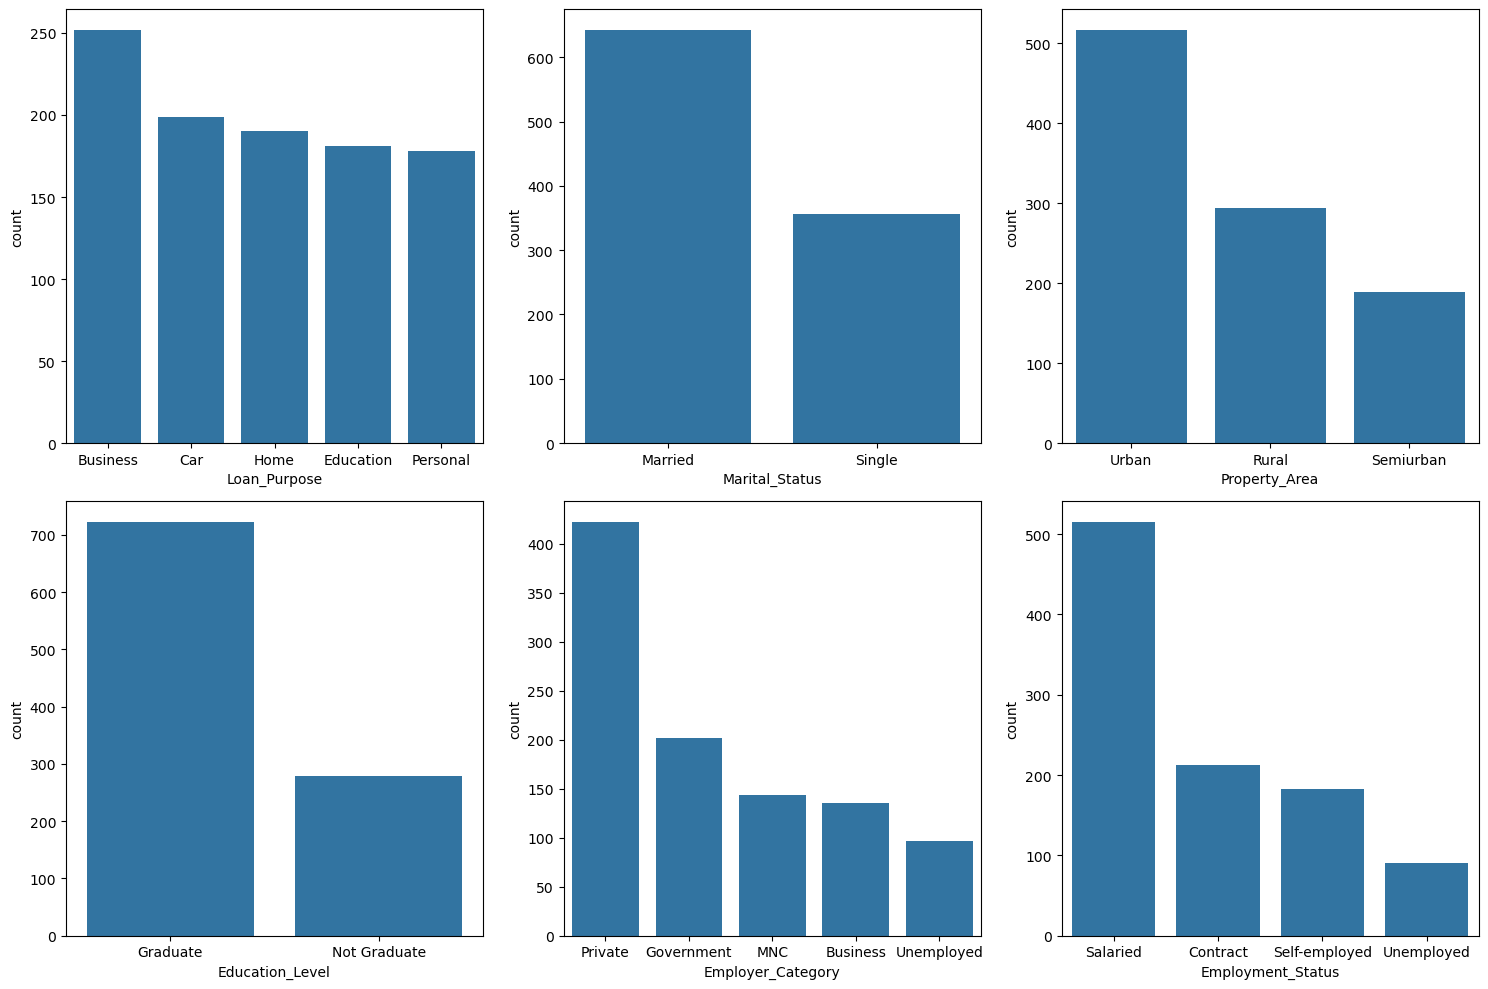

In [191]:
fig, axes = plt.subplots(2,3, figsize=(15,10))

loan_purpose_cnt = df["Loan_Purpose"].value_counts()
sns.barplot( loan_purpose_cnt, ax = axes[0,0])

marital_cnt = df["Marital_Status"].value_counts()
sns.barplot(marital_cnt, ax = axes[0,1])

edulvl_cnt = df["Education_Level"].value_counts()
sns.barplot(edulvl_cnt, ax=axes[1,0])

empl_cnt = df["Employer_Category"].value_counts()
sns.barplot(empl_cnt, ax = axes[1,1])

ppt_cnt = df["Property_Area"].value_counts()
sns.barplot(ppt_cnt, ax = axes[0,2])

empy_cnt = df["Employment_Status"].value_counts()
sns.barplot(empy_cnt, ax=axes[1,2])

fig.tight_layout()

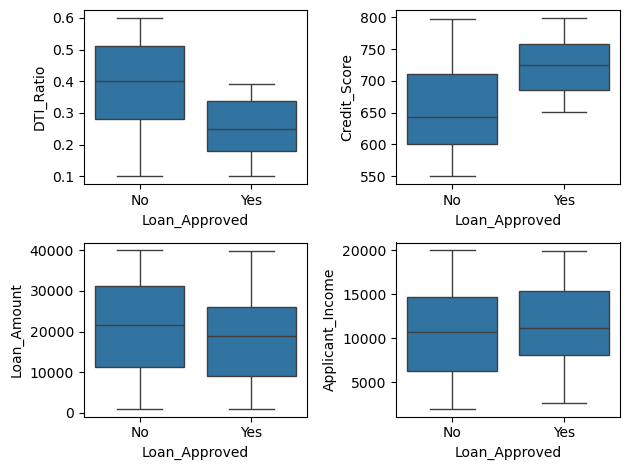

In [192]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0], data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax = axes[0,1], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax = axes[1,0], data=df, x="Loan_Approved", y="Loan_Amount")
sns.boxplot(ax = axes[1,1], data=df, x="Loan_Approved", y="Applicant_Income")
fig.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

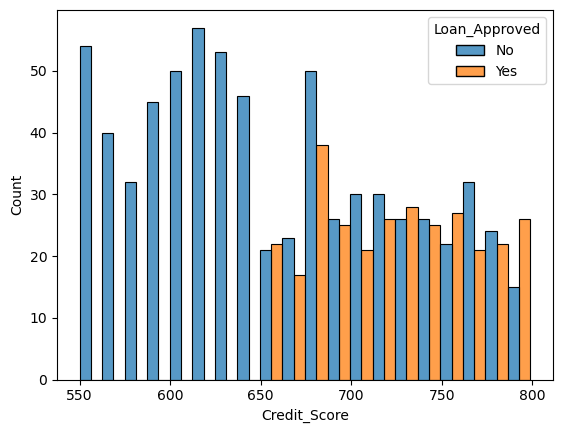

In [193]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

Feature Encoding

In [223]:
df["Loan_Approved"] = df["Loan_Approved"].map({"Yes":1, "No":0})
df["Marital_Status"] = df["Marital_Status"].map({"Married":1, "Single":0})
df["Education_Level"] = df["Education_Level"].map({"Not Graduate":1, "Graduate":0})

cols = ["Gender", "Employer_Category","Property_Area", "Loan_Purpose", "Employment_Status"]
df = pd.get_dummies(df, columns=cols, drop_first=True, dtype=int)

In [200]:
df = df.drop(columns="Applicant_ID")

Correlation Heatmap

<Axes: >

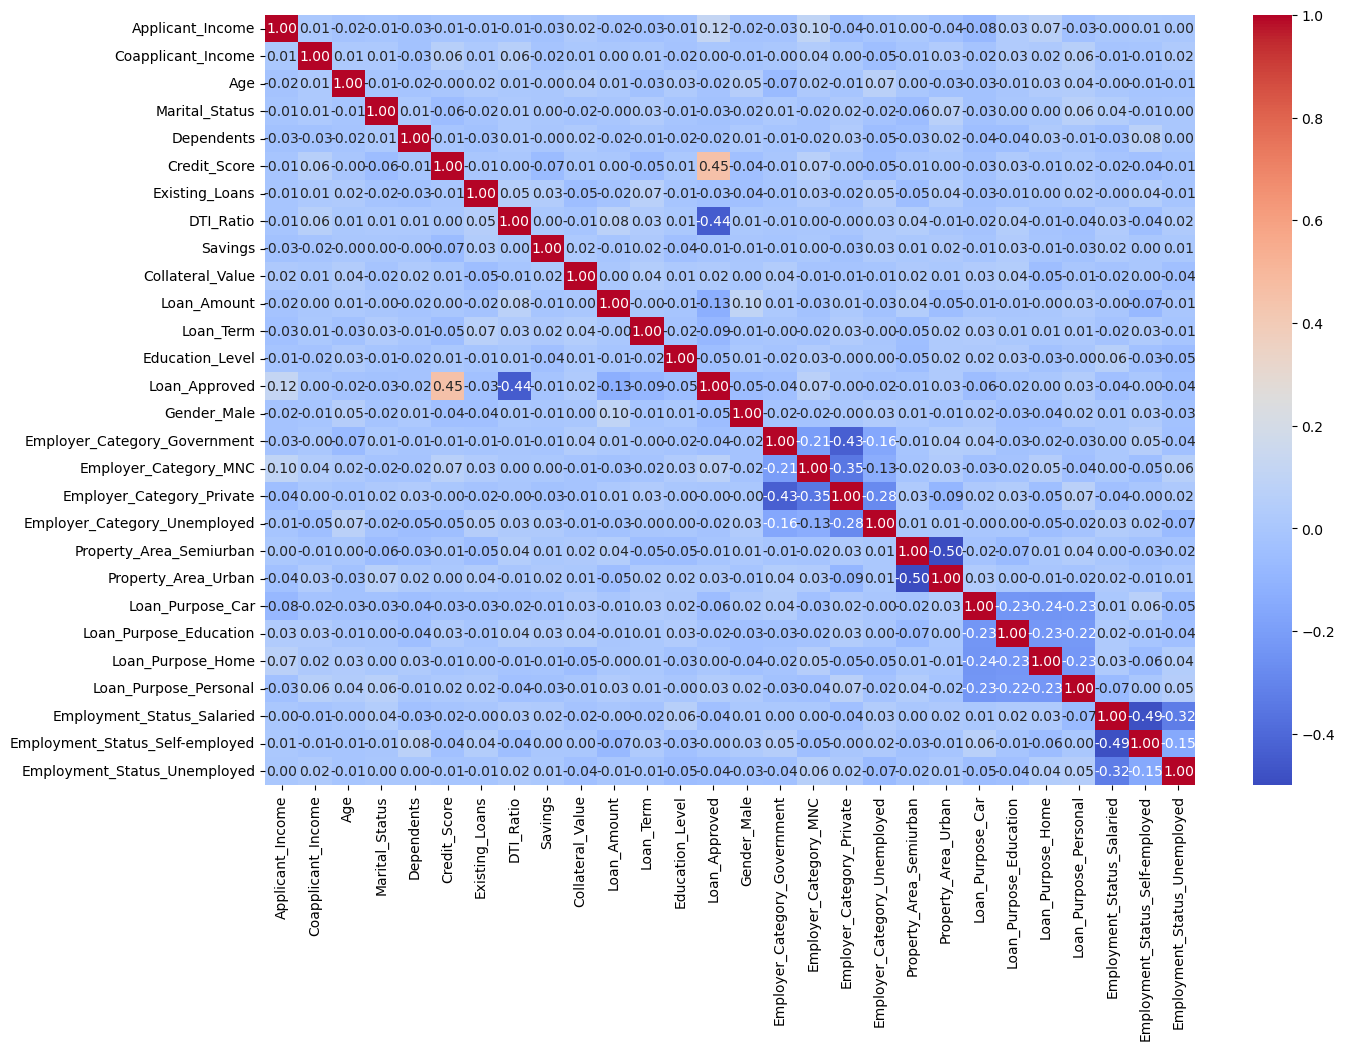

In [203]:
nums_col = df.select_dtypes(include = ["number"])
corr_matrix = nums_col.corr()
corr_matrix["Loan_Approved"].sort_values(ascending=False)

plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"

)

Train_Test_Split

In [204]:

X = df.drop(columns=["Loan_Approved"])
y = df["Loan_Approved"]


In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression

In [206]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
print(f"precision = {precision}%\naccuracy = {accuracy}%\nrecall = {recall}%")

precision = 78.33333333333333%
accuracy = 86.5%
recall = 77.04918032786885%


KNN

In [234]:
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
print(f"precision = {precision}%\naccuracy = {accuracy}%\nrecall = {recall}%")

precision = 67.5%
accuracy = 76.5%
recall = 44.26229508196721%


Gaussian Naive Bayes

In [208]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
print(f"precision = {precision}%\naccuracy = {accuracy}%\nrecall = {recall}%")

precision = 80.35714285714286%
accuracy = 86.5%
recall = 73.77049180327869%


Decision Tree Classifier

In [211]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [212]:
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.        , 0.0011875 , 0.00123611, 0.0016024 , 0.00165628,
       0.00166667, 0.00166667, 0.00183943, 0.0022549 , 0.00229619,
       0.00270846, 0.00277401, 0.003     , 0.0036    , 0.004375  ,
       0.00729167, 0.00769725, 0.01333333, 0.03429896, 0.13858348])

In [213]:
tree = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train, y_train)
    tree.append((model,alpha))

In [214]:
best_acc = 0
best_alpha = 0
for model,alpha in tree:
    acc = model.score(X_test,y_test)
    if acc>best_acc:
        best_acc=acc
        best_alpha=alpha


In [215]:
best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
print(f"precision = {precision}%\naccuracy = {accuracy}%\nrecall = {recall}%")

precision = 83.5820895522388%
accuracy = 92.0%
recall = 91.80327868852459%


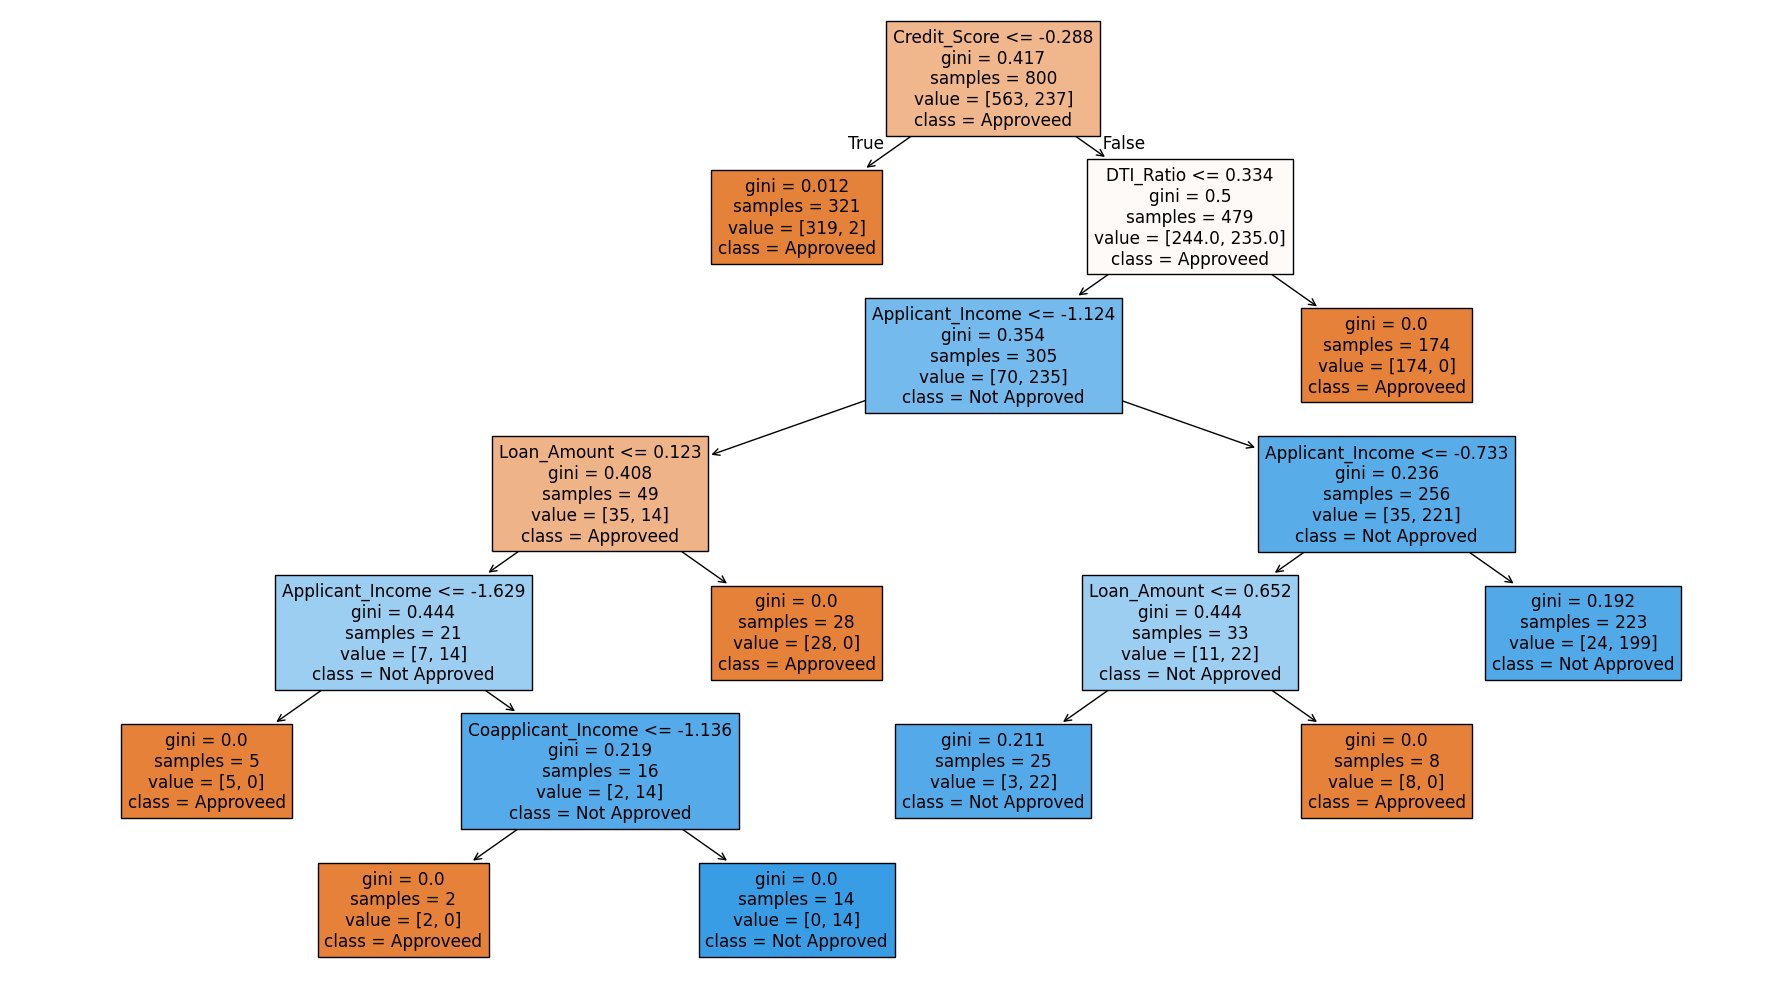

In [218]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names= ["Approveed", "Not Approved"],
    filled=True
)
plt.tight_layout()
plt.show()

SVC

In [225]:
svc = SVC()
svc.fit(X_train,y_train)

SVC()

In [229]:
params = {"kernel":["rbf","sigmoid", "linear", "poly"], "C":[0.01,0.1,0.5,1,5,10,20,50,100]}
grid = GridSearchCV(
    svc,
    params,
    scoring="accuracy",
    cv=5
)
grid.fit(X_train,y_train)
grid.best_params_

{'C': 10, 'kernel': 'rbf'}

In [230]:
best_model = SVC(kernel="rbf", C=10)
best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)

In [231]:
accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
print(f"precision = {precision}%\naccuracy = {accuracy}%\nrecall = {recall}%")

precision = 75.43859649122807%
accuracy = 84.0%
recall = 70.49180327868852%


Random Forest

In [257]:
rf = RandomForestClassifier(oob_score=True, n_estimators=201, random_state=42)
rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
f1 = f1_score(y_test, y_pred)*100
print(f"precision = {precision} %\naccuracy = {accuracy} %\nrecall = {recall} %\nF1 score = {f1} %\nOOB score = {rf.oob_score_*100} %")


precision = 84.12698412698413 %
accuracy = 91.0 %
recall = 86.88524590163934 %
F1 score = 85.48387096774194 %
OOB score = 94.0 %


Feature Scaling

In [246]:
df["Credit_Score_sq"] = df["Credit_Score"]**2
df["DTI_Ratio_sq"] = df["DTI_Ratio"]**2
""" df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"]) """

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

In [252]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

tree = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train, y_train)
    tree.append((model,alpha))

best_acc = 0
best_alpha = 0
for model,alpha in tree:
    acc = model.score(X_test,y_test)
    if acc>best_acc:
        best_acc=acc
        best_alpha=alpha

best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
f1 = f1_score(y_test, y_pred)*100
print(f"precision = {precision}%\naccuracy = {accuracy}%\nrecall = {recall}%\nF1 score = {f1}%")

precision = 83.5820895522388%
accuracy = 92.0%
recall = 91.80327868852459%
F1 score = 87.5%


In [253]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
f1 = f1_score(y_test, y_pred)*100
print(f"precision = {precision}%\naccuracy = {accuracy}%\nrecall = {recall}%\nF1 score = {f1}%")

precision = 78.46153846153847%
accuracy = 88.0%
recall = 83.60655737704919%
F1 score = 80.95238095238095%
